# Experiment 12: Cluster Streaming Data Using Single-Pass K-Means Algorithm

**Aim:** Real time clustering of streaming data using incremental single-pass K-means.

## Theory

K-means normally needs the entire dataset in memory and repeats the assign-and-update cycle many
times until the centroids stop moving. This is not possible for a data stream, where records arrive
continuously and each record can be read only once.

Single-pass K-means solves this by updating the centroids incrementally. The first k records become
the initial centroids. When a new point arrives, the distance to every centroid is calculated and
the point is assigned to the nearest one. That centroid is then moved towards the new point using a
learning rate equal to the running mean:

```text
learning_rate = 1 / count[cluster]

centroid = centroid + learning_rate * (x - centroid)
```

Only the centroid and the count are stored for each cluster, so the memory used stays constant no
matter how long the stream runs, and every point is processed exactly once.

## Data Pipeline

```text
Streaming data input
        |
        v
Complete dataset
        |
        v
Choose k centroids
        |
        v
Assign all data points
        |
        v
Recalculate the centroid
        |
        v
Find the accuracy
        |
        v
Reconstruct the cluster as new data points arrive
```

## Procedural Steps

1. Generate or acquire streaming data.
2. Process one observation at a time.
3. Maintain k cluster centroids.
4. Assign every incoming data point.
5. Update the selected centroid immediately.
6. Avoid storing the complete stream.
7. Visualize cluster formation.
8. Measure the cluster quality.
9. Compare the streaming result with conventional K-Means.
10. Result analysis.

## Requirements

- Python 3.x
- Jupyter Notebook
- NumPy
- Pandas
- Matplotlib
- Scikit-learn

### Step 1: Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

### Step 2: Generate Streaming Dataset

In [2]:
np.random.seed(42)

clusters_1 = np.random.normal(loc=(2, 2), scale=0.6, size=(300, 2))
clusters_2 = np.random.normal(loc=(8, 8), scale=0.7, size=(300, 2))
clusters_3 = np.random.normal(loc=(5, 2), scale=0.5, size=(300, 2))

# combining the cluster vertically
data = np.vstack((clusters_1, clusters_2, clusters_3))

np.random.shuffle(data)

# convert the data into a pandas dataframe
df = pd.DataFrame(data, columns=['feature1', 'feature2'])

print("first five observations")
print(df.head())

first five observations
   feature1  feature2
0  9.712026  8.090455
1  5.608579  2.760658
2  7.571048  7.728609
3  1.908929  2.352990
4  5.245487  2.367439


**Interpretation**

- Three groups of 300 observations are generated around the centres (2, 2), (8, 8) and (5, 2).
- The observations are shuffled so that they arrive in random order, exactly like a real stream.
- The data is stored in a DataFrame only for display; the algorithm itself never needs it.

### Step 3: Single-Pass K-Means Function

In [3]:
def single_pass_kmeans(stream, k):

    stream = np.asarray(stream)

    centroids = stream[:k].copy()
    counts = np.ones(k, dtype=int)

    labels = []
    centroid_history = [centroids.copy()]

    for x in stream[k:]:

        distances = np.linalg.norm(
            centroids - x,
            axis=1
        )

        # Find the nearest centroid
        cluster = np.argmin(distances)

        counts[cluster] += 1

        learning_rate = 1.0 / counts[cluster]

        centroids[cluster] = (
            centroids[cluster]
            + learning_rate * (x - centroids[cluster])
        )

        # Store cluster assignment
        labels.append(cluster)
        centroid_history.append(centroids.copy())

    return (
        np.array(labels),
        np.array(centroid_history),
        counts
    )

**Interpretation**

- The first k observations of the stream become the initial centroids.
- Every remaining observation is read exactly once.
- The nearest centroid is found with the Euclidean distance.
- The learning rate 1 / count makes the update equal to the running mean of that cluster.
- The observation is discarded after the update, so the complete stream is never stored.

### Step 4: Execute the Algorithm

In [4]:
# select the number of clusters
k = 3

# execute the single-pass K-means algorithm
labels, centroid_history, counts = single_pass_kmeans(df.values, k)

final_centroids = centroid_history[-1]

### Step 5: Display the Final Centroids

In [5]:
print("Final Centroids:")

for i, centroid in enumerate(final_centroids):
    print(
        f"Cluster {i}: "
        f"Feature_1={centroid[0]:.3f}, "
        f"Feature_2={centroid[1]:.3f}"
    )

Final Centroids:
Cluster 0: Feature_1=8.529, Feature_2=8.482
Cluster 1: Feature_1=3.503, Feature_2=2.022
Cluster 2: Feature_1=7.760, Feature_2=7.752


### Step 6: Display the Cluster Sizes

In [6]:
print("Cluster counts:")

for i, count in enumerate(counts):
    print(
        f"Cluster {i}: {count} observations"
    )

Cluster counts:
Cluster 0: 123 observations
Cluster 1: 600 observations
Cluster 2: 177 observations


### Step 7: Measure the Cluster Quality

In [7]:
initial_labels = []

for i in range(k):
    distances = np.linalg.norm(
        final_centroids - data[i],
        axis=1
    )
    initial_labels.append(
        np.argmin(distances)
    )

all_labels = np.concatenate([
    np.array(initial_labels),
    labels
])

score = silhouette_score(
    data,
    all_labels
)

print(f"\nSilhouette_score: {score:.4f}")


Silhouette_score: 0.5661


/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


**Interpretation**

- The first k observations were used to initialize the centroids, so they were never given a label
  inside the loop. They are labelled here against the final centroids.
- The silhouette score measures how well each observation fits its own cluster compared to the
  nearest other cluster. It ranges from -1 to 1, and a higher value means better separated clusters.

### Step 8: Visualize Cluster Formation

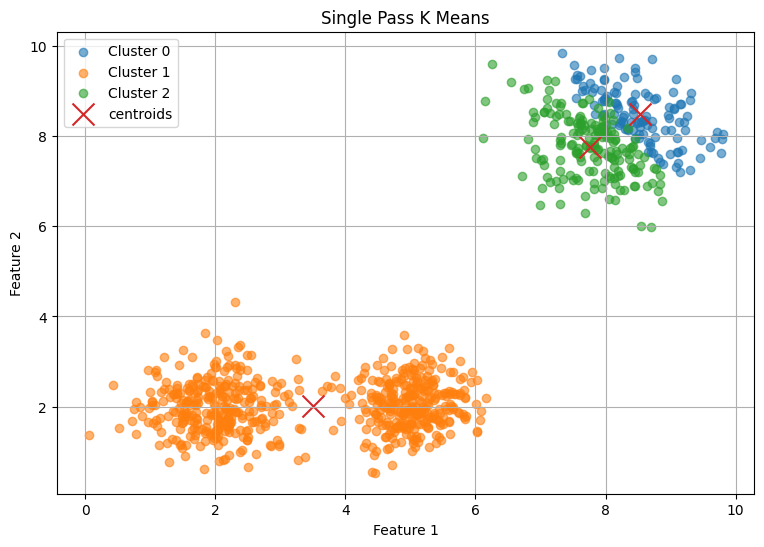

In [8]:
plt.figure(figsize=(9, 6))

for cluster_id in range(k):

    cluster_points = data[
        all_labels == cluster_id
    ]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        label=f"Cluster {cluster_id}",
        alpha=0.6
    )

# Plot the final centroids
plt.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker="x",
    s=250,
    label="centroids"
)

# Add the features for the plot
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Single Pass K Means")
plt.legend()
plt.grid(True)

plt.show()

### Step 9: Compare with Conventional K-Means

In [ ]:
from sklearn.cluster import KMeans

def wcss(points, centroids, cluster_labels):
    total = 0
    for i in range(len(centroids)):
        cluster_points = points[cluster_labels == i]
        total += np.sum((cluster_points - centroids[i]) ** 2)
    return total
wcss_stream = wcss(data, final_centroids, all_labels)
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(data)
score_batch = silhouette_score(data, kmeans.labels_)
wcss_batch = kmeans.inertia_
print("Comparison")
print("Method                  Silhouette      WCSS")
print(f"Single-Pass K-Means     {score:.4f}          {wcss_stream:.2f}")
print(f"Conventional K-Means    {score_batch:.4f}          {wcss_batch:.2f}")
print("Conventional centroids:")
for i, centroid in enumerate(kmeans.cluster_centers_):
    print(
        f"Cluster {i}: "
        f"Feature_1={centroid[0]:.3f}, "
        f"Feature_2={centroid[1]:.3f}"
    )

Comparison

Method                  Silhouette      WCSS
Single-Pass K-Means     0.5661          1931.72
Conventional K-Means    0.7275          643.23

Conventional centroids:
Cluster 0: Feature_1=8.075, Feature_2=8.051
Cluster 1: Feature_1=5.009, Feature_2=2.057
Cluster 2: Feature_1=1.987, Feature_2=1.988


/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithkumar/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

### Step 10: Result Analysis

In [ ]:
print("Result Analysis")
print("Observations processed  :", len(data))
print("Observations stored     :", 0)
print("Values kept in memory   :", k, "centroids and", k, "counts")
print("Passes over the data")
print("  Single-Pass K-Means  : 1")
print("  Conventional K-Means :", kmeans.n_iter_, "iterations over the full dataset")
print(f"Difference in Silhouette: {score - score_batch:.4f}")
print(f"Difference in WCSS      : {wcss_stream - wcss_batch:.2f}")

Result Analysis

Observations processed  : 900
Observations stored     : 0
Values kept in memory   : 3 centroids and 3 counts

Passes over the data
  Single-Pass K-Means  : 1
  Conventional K-Means : 2 iterations over the full dataset

Difference in Silhouette: -0.1615
Difference in WCSS      : 1288.48


## Interpretation

- A stream of 900 observations belonging to three natural groups is generated and shuffled.
- The first 3 observations become the initial centroids.
- Each remaining observation is read once, assigned to the nearest centroid and then discarded.
- The centroid is corrected by the learning rate 1 / count, which is the running mean.
- Only k centroids and k counts are stored, so the memory does not grow with the stream.
- The final centroids are (8.529, 8.482), (3.503, 2.022) and (7.760, 7.752), and the cluster sizes
  are 123, 600 and 177.
- With the seed 42 the first three observations happened to include two points from the region
  around (8, 8), so two centroids started in the same group. As a result the groups near (2, 2) and
  (5, 2) were merged into a single cluster of 600 observations.
- This shows the main limitation of single-pass K-Means: the result depends strongly on which
  observations arrive first, because there is no second pass to correct a poor initialization.
- The silhouette score of 0.5661 still indicates reasonably separated clusters.
- Conventional K-Means, which stores the whole dataset and repeats the assign-and-update cycle,
  recovers all three true centres and reaches a higher silhouette score of 0.7275 with a much lower
  WCSS.

## Result

The streaming data was successfully clustered in real time using the incremental single-pass K-Means
algorithm. Each observation was processed exactly once, the selected centroid was updated
immediately using the learning rate 1 / count, and the complete stream was never stored. The cluster
quality was measured using the silhouette score and compared with conventional K-Means, showing that
the single-pass method clusters a stream in one pass with constant memory, at the cost of being
sensitive to the order in which the observations arrive.